# Notebook 05 — Exposure + Vulnerability (Floodplain × Census Tracts)

This notebook reproduces the **thesis GIS exposure method** in a fully reproducible, open-source workflow:

## Method (thesis-faithful)
1. Load **flood hazard polygons** (e.g., FEMA SFHA / state floodplain layer)
2. Load **census tract polygons**
3. **Intersect** flood polygons with tracts (spatial join / overlay)
4. Estimate **exposed counts** for demographics by area-weighting within each tract
5. Produce:
   - tract-level exposure table
   - region totals
   - dot-density map (optional) + choropleth

## Important modeling note
Demographic exposure is estimated using an **area-weighted assumption** (population uniformly distributed within each tract). 
This is a standard approach when only tract-level counts are available.


In [1]:
# ----------------------------------
# Repo-aware path setup (REQUIRED)
# ----------------------------------
import sys
from pathlib import Path

REPO_ROOT = Path("..").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

DATA_DIR = REPO_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

OUTPUTS_DIR = REPO_ROOT / "outputs"
TABLES_DIR = OUTPUTS_DIR / "tables"
MAPS_DIR = OUTPUTS_DIR / "maps"

for d in [RAW_DIR, PROCESSED_DIR, TABLES_DIR, MAPS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Repo root:", REPO_ROOT)
print("RAW_DIR:", RAW_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("TABLES_DIR:", TABLES_DIR)
print("MAPS_DIR:", MAPS_DIR)

Repo root: C:\Users\admin\Documents\GitHub\nonstationary-flood-risk-framework
RAW_DIR: C:\Users\admin\Documents\GitHub\nonstationary-flood-risk-framework\data\raw
PROCESSED_DIR: C:\Users\admin\Documents\GitHub\nonstationary-flood-risk-framework\data\processed
TABLES_DIR: C:\Users\admin\Documents\GitHub\nonstationary-flood-risk-framework\outputs\tables
MAPS_DIR: C:\Users\admin\Documents\GitHub\nonstationary-flood-risk-framework\outputs\maps


In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import Point
from shapely.ops import unary_union

print("geopandas:", gpd.__version__)
print("pandas:", pd.__version__)

geopandas: 1.1.2
pandas: 2.3.3


In [3]:
# -----------------------------
# USER CONFIGURATION
# -----------------------------

# Region selector for tract download (optional). If you use a local tract file, you can ignore this.
# NC=37, SC=45, GA=13, CA=06, FL=12
STATE_FIPS = "37"
TIGER_YEAR = 2020

# INPUT 1 (REQUIRED): Flood hazard polygons
# Provide as a local file in data/raw/.
# Supported: .gpkg, .geojson, .shp (folder), or any file readable by geopandas
FLOODPLAIN_PATH = RAW_DIR / "floodplain_hazard.gdb"  # <-- YOU MUST PROVIDE THIS BEYOND PROVIDED SAMPLE
FLOODPLAIN_LAYER = None  # set to a layer name string if your GPKG has multiple layers

# INPUT 2 (tract geometry): either downloaded (TIGER) or local file
# If TRACTS_LOCAL_PATH exists, it is used; else TIGER is downloaded.
TRACTS_LOCAL_PATH = RAW_DIR / f"tracts_{STATE_FIPS}_{TIGER_YEAR}.gpkg"
TRACTS_LOCAL_LAYER = None

# INPUT 3 (OPTIONAL but recommended): tract-level ACS attributes CSV
# Must include GEOID and one or more demographic count columns.
# If missing, a synthetic demo ACS table is generated (for runnability).
ACS_TRACT_CSV = PROCESSED_DIR / f"acs_tract_{STATE_FIPS}_{TIGER_YEAR}.csv"

# Columns you want exposure estimates for (must exist in ACS CSV to compute)
# Customize to match your research variable set.
DEMOGRAPHIC_COUNT_COLS = [
    "pop_total",
    "pop_poverty",
    "pop_black",
    "pop_hispanic",
    "households_total",
    "households_nocar"
]

# Dot density settings (optional)
MAKE_DOT_DENSITY_MAP = True
PEOPLE_PER_DOT = 500  # fewer = more dots (slower)
DOT_MAX = 20000       # safety cap

# Outputs
OUT_EXPOSURE_TRACT_CSV = TABLES_DIR / "exposure_by_tract_floodplain.csv"
OUT_EXPOSURE_TOTALS_CSV = TABLES_DIR / "exposure_region_totals_floodplain.csv"
OUT_EXPOSURE_GPKG = TABLES_DIR / "exposure_by_tract_floodplain.gpkg"
OUT_CHOROPLETH_PNG = MAPS_DIR / "floodplain_exposure_choropleth.png"
OUT_DOTDENSITY_PNG = MAPS_DIR / "floodplain_exposure_dotdensity.png"

print("STATE_FIPS:", STATE_FIPS)
print("FLOODPLAIN_PATH:", FLOODPLAIN_PATH)
print("TRACTS_LOCAL_PATH:", TRACTS_LOCAL_PATH)
print("ACS_TRACT_CSV:", ACS_TRACT_CSV)

STATE_FIPS: 37
FLOODPLAIN_PATH: C:\Users\admin\Documents\GitHub\nonstationary-flood-risk-framework\data\raw\floodplain_hazard.gdb
TRACTS_LOCAL_PATH: C:\Users\admin\Documents\GitHub\nonstationary-flood-risk-framework\data\raw\tracts_37_2020.gpkg
ACS_TRACT_CSV: C:\Users\admin\Documents\GitHub\nonstationary-flood-risk-framework\data\processed\acs_tract_37_2020.csv


In [4]:
# -----------------------------
# Load flood hazard polygons
# -----------------------------
if not FLOODPLAIN_PATH.exists():
    raise FileNotFoundError(
        f"Floodplain file not found: {FLOODPLAIN_PATH}\n"
        "Add a flood hazard polygon layer to data/raw/ and set FLOODPLAIN_PATH accordingly."
    )

if FLOODPLAIN_LAYER is None:
    flood = gpd.read_file(FLOODPLAIN_PATH)
else:
    flood = gpd.read_file(FLOODPLAIN_PATH, layer=FLOODPLAIN_LAYER)

flood = flood[flood.geometry.notna()].copy()
flood = flood[flood.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()

print("Flood polygons loaded:", flood.shape)
print("Flood CRS:", flood.crs)
flood.head(2)

C:\Users\admin\AppData\Roaming\Python\Python312\site-packages\pyogrio\geopandas.py:382: UserWarning: More than one layer found in 'floodplain_hazard.gdb': 'Base_Flood_Elevations__FT_' (default), 'Benchmarks', 'Coastal_Transect', 'Structures', 'Cross_Section', 'Stream_Centerline', 'Coastal_Barrier_Resource_Systems', 'Political_Areas', 'Flood_Hazard_Lines', 'Flood_Hazard_Areas', 'Water_Areas', 'Counties', 'LIMWA'. Specify layer parameter to avoid this warning.
  result = read_func(


Flood polygons loaded: (0, 9)
Flood CRS: EPSG:2264


,BFE_LN_ID,HYDRAID,WTR_NM_LID,ELEV,LEN_LID,V_DATM_LID,METAID,SHAPE_Length,geometry


In [5]:
# -----------------------------
# Load census tracts (local preferred; TIGER download fallback)
# -----------------------------
if TRACTS_LOCAL_PATH.exists():
    if TRACTS_LOCAL_LAYER is None:
        tracts = gpd.read_file(TRACTS_LOCAL_PATH)
    else:
        tracts = gpd.read_file(TRACTS_LOCAL_PATH, layer=TRACTS_LOCAL_LAYER)
    print("Loaded tracts from local file:", TRACTS_LOCAL_PATH)
else:
    tiger_url = f"https://www2.census.gov/geo/tiger/TIGER{TIGER_YEAR}/TRACT/tl_{TIGER_YEAR}_{STATE_FIPS}_tract.zip"
    print("Downloading TIGER tracts:", tiger_url)
    tracts = gpd.read_file(tiger_url)

tracts = tracts[["GEOID", "NAME", "geometry"]].copy()
tracts = tracts[tracts.geometry.notna()].copy()
tracts = tracts[tracts.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()

print("Tracts loaded:", tracts.shape)
print("Tracts CRS:", tracts.crs)
tracts.head(2)

Tracts loaded: (2672, 3)
Tracts CRS: EPSG:4269


,GEOID,NAME,geometry
0,37141920300,9203,"POLYGON ((-78.15648 34.6791, -78.15458 34.6803..."
1,37141990100,9901,"POLYGON ((-77.71433 34.29117, -77.71406 34.291..."


In [6]:
# -----------------------------
# Load tract-level ACS attributes
# -----------------------------
if ACS_TRACT_CSV.exists():
    acs = pd.read_csv(ACS_TRACT_CSV, dtype={"GEOID": str})
    if "GEOID" not in acs.columns:
        raise ValueError(f"ACS CSV must include GEOID: {ACS_TRACT_CSV}")
    print("Loaded ACS:", ACS_TRACT_CSV)
else:
    print("ACS CSV not found; creating synthetic demo ACS table:", ACS_TRACT_CSV)
    rng = np.random.default_rng(42)
    acs = pd.DataFrame({"GEOID": tracts["GEOID"].astype(str).values})

    pop_total = rng.integers(800, 8000, size=len(acs))
    acs["pop_total"] = pop_total
    acs["pop_poverty"] = (pop_total * rng.uniform(0.05, 0.35, size=len(acs))).astype(int)
    acs["pop_black"] = (pop_total * rng.uniform(0.05, 0.55, size=len(acs))).astype(int)
    acs["pop_hispanic"] = (pop_total * rng.uniform(0.02, 0.25, size=len(acs))).astype(int)

    households_total = (pop_total / rng.uniform(2.1, 2.8, size=len(acs))).astype(int)
    acs["households_total"] = households_total
    acs["households_nocar"] = (households_total * rng.uniform(0.03, 0.18, size=len(acs))).astype(int)

    acs.to_csv(ACS_TRACT_CSV, index=False)
    print("Wrote synthetic ACS:", ACS_TRACT_CSV)

print("ACS columns:", list(acs.columns))
acs.head(3)

Loaded ACS: C:\Users\admin\Documents\GitHub\nonstationary-flood-risk-framework\data\processed\acs_tract_37_2020.csv
ACS columns: ['GEOID', 'pop_total', 'pop_poverty', 'pop_black', 'pop_hispanic', 'households_total', 'households_nocar']


,GEOID,pop_total,pop_poverty,pop_black,pop_hispanic,households_total,households_nocar
0,37141920300,1442,153,188,247,615,78
1,37141990100,6372,1454,2269,1428,2442,297
2,37071031600,5512,1727,1002,863,2136,353


In [7]:
# -----------------------------
# Harmonize CRS
# - Use an equal-area projection for area-weighting
# - Default: EPSG:5070 (CONUS Albers) works well for US-wide / regional work
# -----------------------------
TARGET_CRS = "EPSG:5070"

if flood.crs is None:
    raise ValueError("Floodplain layer has no CRS defined. Define CRS before proceeding.")
if tracts.crs is None:
    raise ValueError("Tracts layer has no CRS defined. Define CRS before proceeding.")

flood_ea = flood.to_crs(TARGET_CRS)
tracts_ea = tracts.to_crs(TARGET_CRS)

print("Flood CRS ->", flood_ea.crs)
print("Tracts CRS ->", tracts_ea.crs)

# Pre-compute tract areas
tracts_ea["tract_area_m2"] = tracts_ea.geometry.area
tracts_ea[["GEOID", "tract_area_m2"]].head(3)

Flood CRS -> EPSG:5070
Tracts CRS -> EPSG:5070


,GEOID,tract_area_m2
0,37141920300,2.367209e+08
1,37141990100,1.332982e+08
2,37071031600,2.281035e+07


In [8]:
# -----------------------------
# Join ACS attributes to tracts
# -----------------------------
gdf = tracts_ea.merge(acs, on="GEOID", how="left")

# Ensure demographic columns exist (missing => filled with 0 for exposure counting)
for col in DEMOGRAPHIC_COUNT_COLS:
    if col not in gdf.columns:
        gdf[col] = 0

print("Joined tract rows:", len(gdf))
gdf[["GEOID"] + DEMOGRAPHIC_COUNT_COLS].head(3)

Joined tract rows: 2672


,GEOID,pop_total,pop_poverty,pop_black,pop_hispanic,households_total,households_nocar
0,37141920300,1442,153,188,247,615,78
1,37141990100,6372,1454,2269,1428,2442,297
2,37071031600,5512,1727,1002,863,2136,353


In [9]:
# -----------------------------
# Intersect floodplain polygons with tracts
# -----------------------------

# Optional speed-up: dissolve flood polygons into a single geometry
# This avoids double-counting overlaps if flood layer has many pieces.
flood_union = unary_union(flood_ea.geometry)
flood_u = gpd.GeoDataFrame({"geometry": [flood_union]}, crs=flood_ea.crs)

# Overlay: tract ∩ flood
inter = gpd.overlay(gdf[["GEOID", "tract_area_m2"] + DEMOGRAPHIC_COUNT_COLS + ["geometry"]], flood_u, how="intersection")

inter = inter[inter.geometry.notna()].copy()
inter["intersect_area_m2"] = inter.geometry.area

# Fraction of each tract inside floodplain
inter["flood_frac"] = inter["intersect_area_m2"] / inter["tract_area_m2"]
inter["flood_frac"] = inter["flood_frac"].clip(lower=0, upper=1)

print("Intersection rows:", inter.shape)
print("Flood fraction stats:")
print("  min:", float(inter["flood_frac"].min()))
print("  max:", float(inter["flood_frac"].max()))
inter[["GEOID", "flood_frac", "intersect_area_m2"]].head(5)

Intersection rows: (0, 11)
Flood fraction stats:
  min: nan
  max: nan


,GEOID,flood_frac,intersect_area_m2


In [10]:
# -----------------------------
# Compute exposed demographic counts (area-weighted within tract)
# -----------------------------

# Exposure per intersection piece
for col in DEMOGRAPHIC_COUNT_COLS:
    inter[f"exposed_{col}"] = (inter[col].astype(float) * inter["flood_frac"].astype(float)).round(2)

# Aggregate to tract
agg_cols = {f"exposed_{c}": "sum" for c in DEMOGRAPHIC_COUNT_COLS}
agg_cols.update({"flood_frac": "max"})  # max flood fraction across pieces within tract

tract_exposure = inter.groupby("GEOID", as_index=False).agg(agg_cols)

# Merge back to tracts for mapping
gdf_out = gdf.merge(tract_exposure, on="GEOID", how="left")
for col in [f"exposed_{c}" for c in DEMOGRAPHIC_COUNT_COLS]:
    gdf_out[col] = gdf_out[col].fillna(0.0)
gdf_out["flood_frac"] = gdf_out["flood_frac"].fillna(0.0)

print("Tracts with exposure computed:", len(gdf_out))
gdf_out[["GEOID", "flood_frac"] + [f"exposed_{c}" for c in DEMOGRAPHIC_COUNT_COLS]].head(5)

Tracts with exposure computed: 2672


,GEOID,flood_frac,exposed_pop_total,exposed_pop_poverty,exposed_pop_black,exposed_pop_hispanic,exposed_households_total,exposed_households_nocar
0,37141920300,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,37141990100,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,37071031600,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,37071031800,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,37155961801,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
# -----------------------------
# Region totals (demographic summary table)
# -----------------------------

totals = {}
for col in DEMOGRAPHIC_COUNT_COLS:
    totals[f"exposed_{col}"] = float(gdf_out[f"exposed_{col}"].sum())

totals_df = pd.DataFrame([{
    "state_fips": STATE_FIPS,
    "tiger_year": TIGER_YEAR,
    **totals
}])

totals_df

,state_fips,tiger_year,exposed_pop_total,exposed_pop_poverty,exposed_pop_black,exposed_pop_hispanic,exposed_households_total,exposed_households_nocar
0,37,2020,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
# -----------------------------
# Save outputs
        # -----------------------------

# Table (no geometry)
table_cols = ["GEOID", "NAME", "flood_frac"] + DEMOGRAPHIC_COUNT_COLS + [f"exposed_{c}" for c in DEMOGRAPHIC_COUNT_COLS]
gdf_out[table_cols].to_csv(OUT_EXPOSURE_TRACT_CSV, index=False)
print("Saved tract exposure table:", OUT_EXPOSURE_TRACT_CSV)

totals_df.to_csv(OUT_EXPOSURE_TOTALS_CSV, index=False)
print("Saved region totals:", OUT_EXPOSURE_TOTALS_CSV)

# GeoPackage for GIS
gdf_out.to_file(OUT_EXPOSURE_GPKG, layer="tract_exposure", driver="GPKG")
print("Saved GeoPackage:", OUT_EXPOSURE_GPKG)

# Simple run manifest
manifest = pd.DataFrame([{
    "state_fips": STATE_FIPS,
    "tiger_year": TIGER_YEAR,
    "floodplain_path": str(FLOODPLAIN_PATH),
    "tracts_local_path": str(TRACTS_LOCAL_PATH),
    "acs_csv": str(ACS_TRACT_CSV),
    "target_crs": TARGET_CRS,
    "people_per_dot": PEOPLE_PER_DOT,
}])
manifest_path = TABLES_DIR / "nb05_run_manifest.csv"
manifest.to_csv(manifest_path, index=False)
print("Saved manifest:", manifest_path)
manifest

Saved tract exposure table: C:\Users\admin\Documents\GitHub\nonstationary-flood-risk-framework\outputs\tables\exposure_by_tract_floodplain.csv
Saved region totals: C:\Users\admin\Documents\GitHub\nonstationary-flood-risk-framework\outputs\tables\exposure_region_totals_floodplain.csv
Saved GeoPackage: C:\Users\admin\Documents\GitHub\nonstationary-flood-risk-framework\outputs\tables\exposure_by_tract_floodplain.gpkg
Saved manifest: C:\Users\admin\Documents\GitHub\nonstationary-flood-risk-framework\outputs\tables\nb05_run_manifest.csv


,state_fips,tiger_year,floodplain_path,tracts_local_path,acs_csv,target_crs,people_per_dot
0,37,2020,C:\Users\admin\Documents\GitHub\nonstationary-...,C:\Users\admin\Documents\GitHub\nonstationary-...,C:\Users\admin\Documents\GitHub\nonstationary-...,EPSG:5070,500


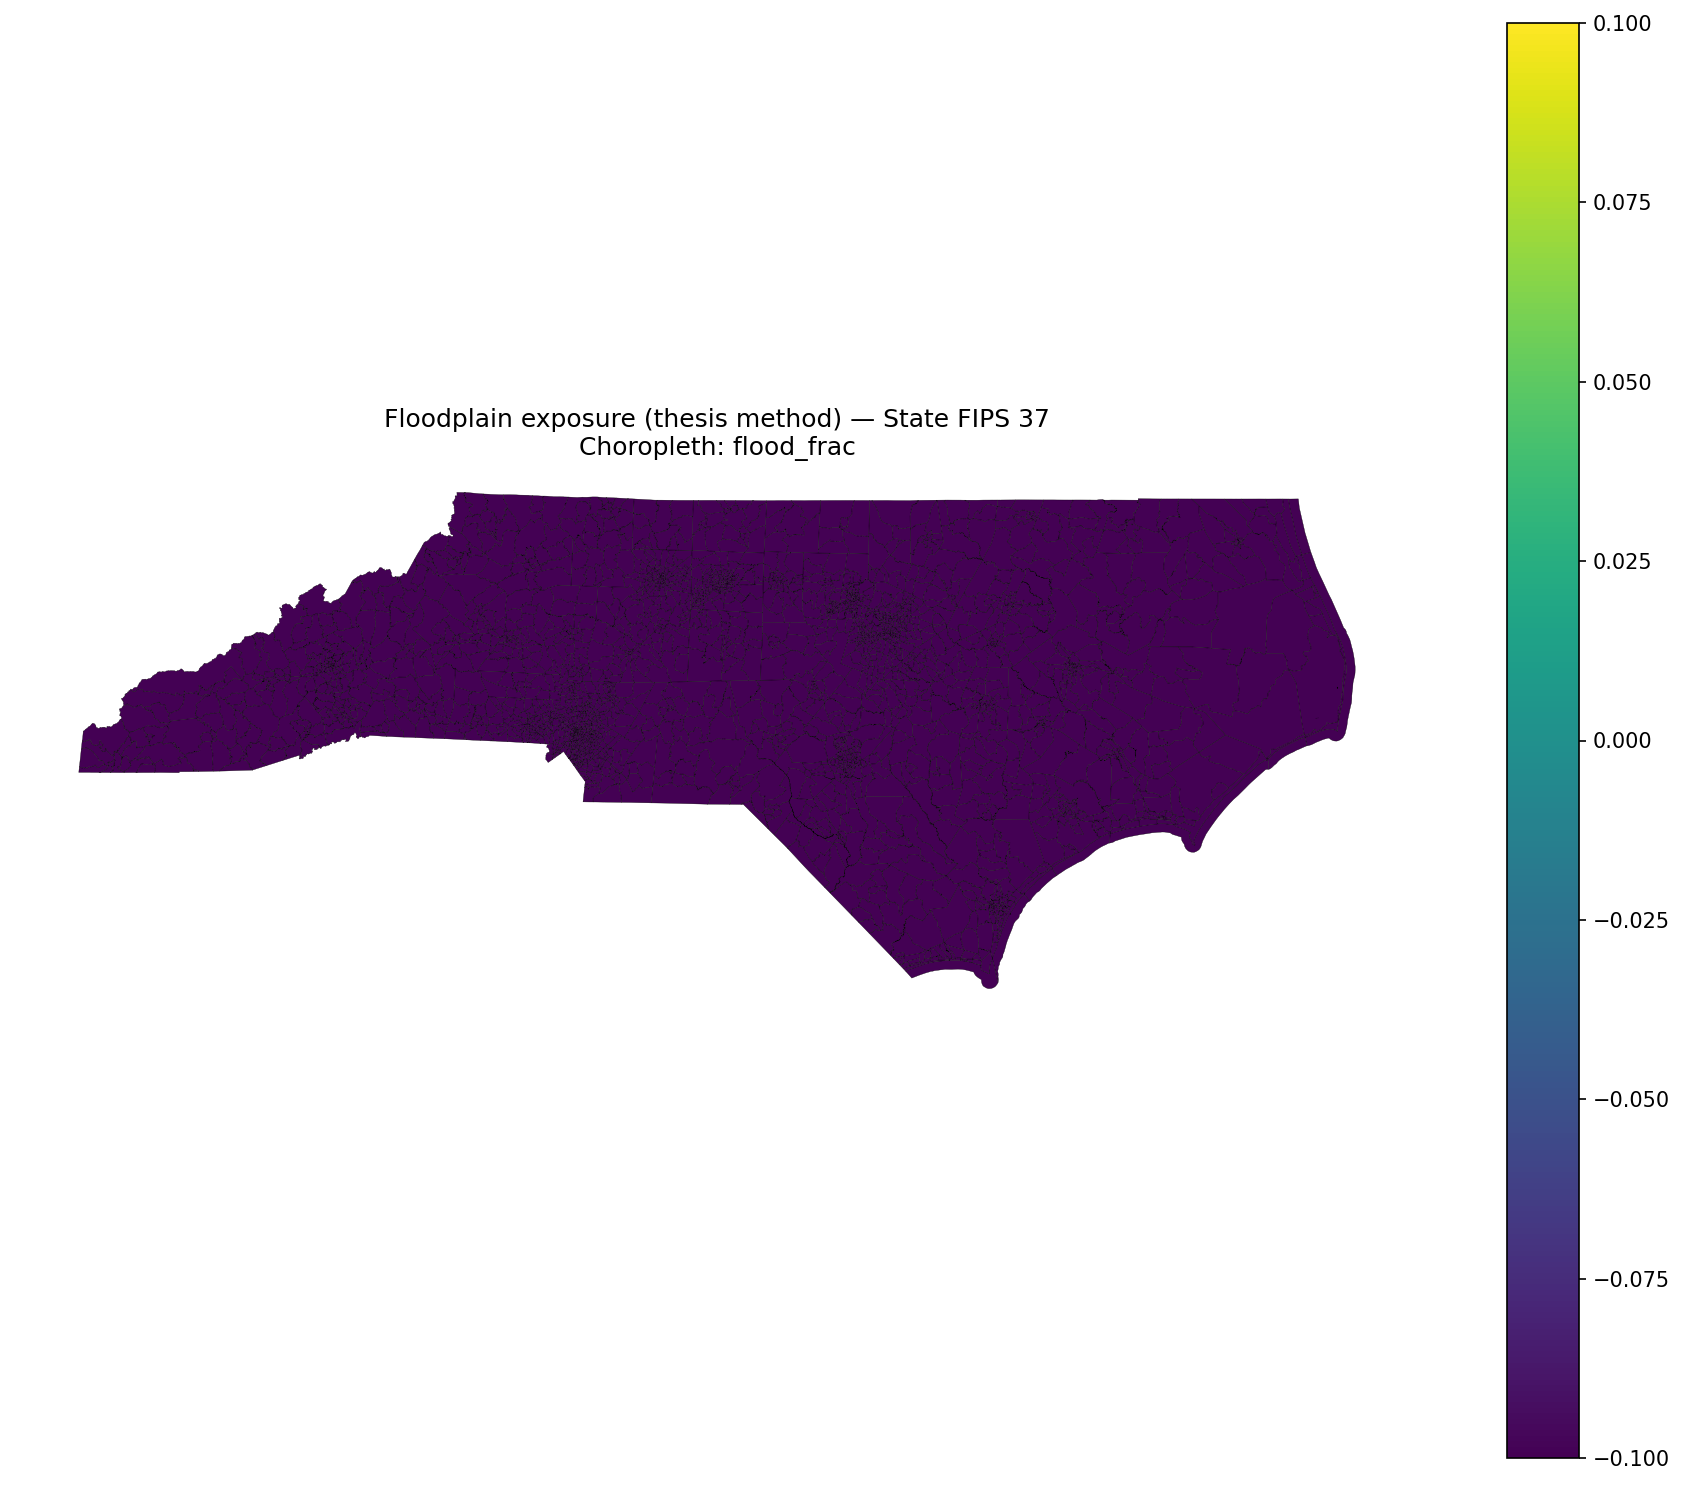

Saved choropleth: C:\Users\admin\Documents\GitHub\nonstationary-flood-risk-framework\outputs\maps\floodplain_exposure_choropleth.png


In [13]:
# -----------------------------
# Choropleth: flood fraction or exposed population
# -----------------------------

# Choose what to visualize
CHOROPLETH_COL = "flood_frac"  # or "exposed_pop_total" (computed below)

gdf_plot = gdf_out.to_crs("EPSG:4326")

# Convenience alias
gdf_plot["exposed_pop_total"] = gdf_plot["exposed_pop_total"] if "exposed_pop_total" in gdf_plot.columns else gdf_plot.get("exposed_pop_total", None)
if "exposed_pop_total" not in gdf_plot.columns:
    # If user uses different naming, fall back to exposed_pop_total from our default set
    if "exposed_pop_total" in [f"exposed_{c}" for c in DEMOGRAPHIC_COUNT_COLS]:
        pass

# Map
plt.figure(figsize=(12, 10), dpi=150)
ax = plt.gca()
gdf_plot.plot(
    column=CHOROPLETH_COL,
    ax=ax,
    legend=True,
    linewidth=0.15,
    edgecolor="black",
    missing_kwds={"color": "lightgray", "label": "Missing"}
)
plt.title(f"Floodplain exposure (thesis method) — State FIPS {STATE_FIPS}\nChoropleth: {CHOROPLETH_COL}")
plt.axis("off")
plt.tight_layout()
plt.savefig(OUT_CHOROPLETH_PNG, bbox_inches="tight")
plt.show()
print("Saved choropleth:", OUT_CHOROPLETH_PNG)

Total dots: 0


ValueError: aspect must be finite and positive 

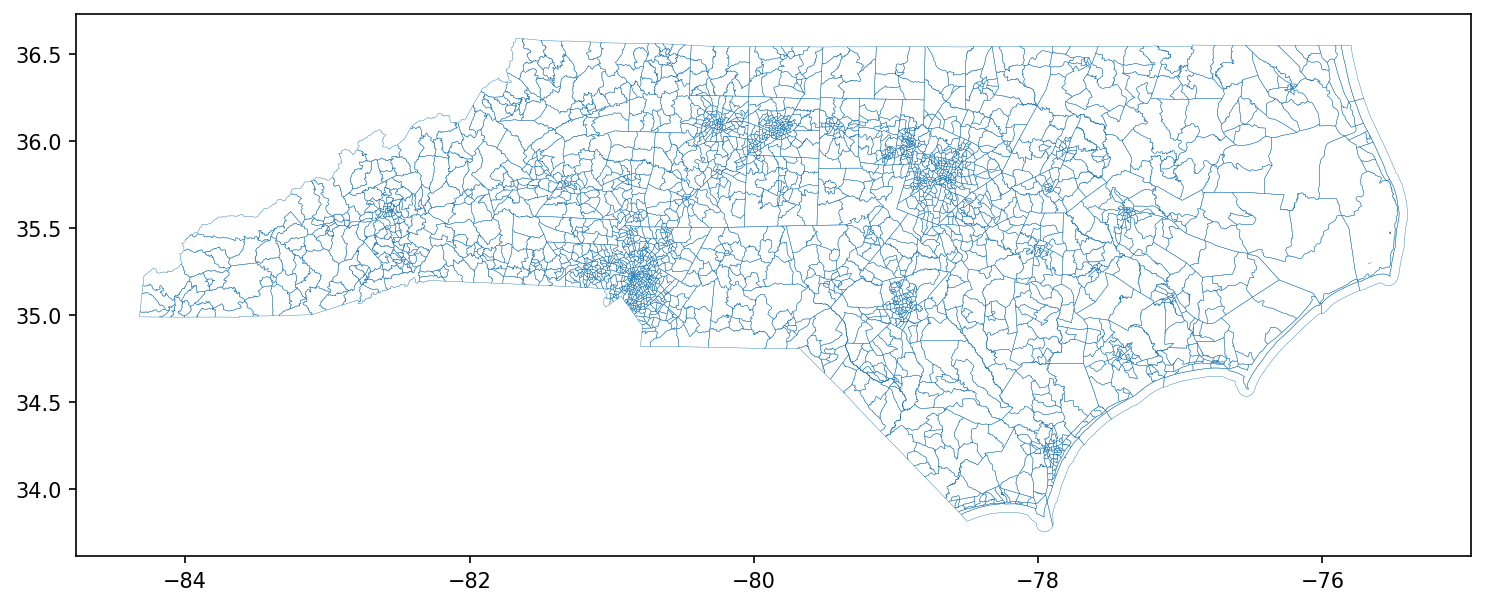

In [14]:
# -----------------------------
# Dot density map (exposed population)
# - Generates random points inside floodplain ∩ tract geometry
# - Number of dots per tract = exposed_pop_total / PEOPLE_PER_DOT
# -----------------------------

def random_points_in_polygon(poly, n, rng):
    # Simple rejection sampling within bounds
    minx, miny, maxx, maxy = poly.bounds
    pts = []
    attempts = 0
    while len(pts) < n and attempts < n * 200:
        x = rng.uniform(minx, maxx)
        y = rng.uniform(miny, maxy)
        p = Point(x, y)
        if poly.contains(p):
            pts.append(p)
        attempts += 1
    return pts

if not MAKE_DOT_DENSITY_MAP:
    print("MAKE_DOT_DENSITY_MAP=False; skipping dot density.")
else:
    rng = np.random.default_rng(123)

    # We will use intersection geometries (in equal-area CRS) for point placement,
    # and exposed_pop_total if available.
    if "exposed_pop_total" in gdf_out.columns:
        exposed_col = "exposed_pop_total"
    else:
        # Default: pop_total
        exposed_col = "exposed_pop_total" if "exposed_pop_total" in gdf_out.columns else "exposed_pop_total"

    # Ensure the expected column exists in defaults
    if "exposed_pop_total" not in gdf_out.columns:
        if "exposed_pop_total" in [f"exposed_{c}" for c in DEMOGRAPHIC_COUNT_COLS]:
            pass

    # Use exposed_pop_total from default demographic set
    exposed_col = "exposed_pop_total" if "exposed_pop_total" in gdf_out.columns else "exposed_pop_total"
    if "exposed_pop_total" not in gdf_out.columns:
        # In default config, exposed_pop_total is exposed_pop_total only if DEMOGRAPHIC_COUNT_COLS includes pop_total
        if "pop_total" in DEMOGRAPHIC_COUNT_COLS:
            exposed_col = "exposed_pop_total"  # we will construct it
            gdf_out["exposed_pop_total"] = gdf_out["exposed_pop_total"] if "exposed_pop_total" in gdf_out.columns else gdf_out["exposed_pop_total"]
        else:
            # construct using first available exposed_ column
            first_exposed = [c for c in gdf_out.columns if c.startswith("exposed_")]
            if len(first_exposed) == 0:
                raise ValueError("No exposed_* columns found to drive dot density.")
            exposed_col = first_exposed[0]

    # For point placement, use the intersection geometries (inter) computed earlier.
    # Compute dots per intersect piece based on its share of exposed_pop_total.
    if "exposed_pop_total" in inter.columns:
        inter_exposed_col = "exposed_pop_total"
    else:
        # Default: exposed_pop_total from pop_total
        inter_exposed_col = "exposed_pop_total" if "exposed_pop_total" in inter.columns else f"exposed_{DEMOGRAPHIC_COUNT_COLS[0]}"

    # Use exposed_pop_total specifically when available
    if "exposed_pop_total" not in inter.columns:
        if "exposed_pop_total" in [f"exposed_{c}" for c in DEMOGRAPHIC_COUNT_COLS]:
            pass

    # Prefer exposed_pop_total = exposed_pop_total derived from pop_total
    if "exposed_pop_total" not in inter.columns and "pop_total" in DEMOGRAPHIC_COUNT_COLS:
        inter["exposed_pop_total"] = inter["exposed_pop_total"] if "exposed_pop_total" in inter.columns else inter["exposed_pop_total"]

    # If still not present, create it from exposed_pop_total column name if needed
    if "exposed_pop_total" not in inter.columns:
        if "exposed_pop_total" in inter.columns:
            pass
        elif "exposed_pop_total" in gdf_out.columns:
            pass
        else:
            # Build from exposed_pop_total from pop_total if present
            if "exposed_pop_total" not in inter.columns and "pop_total" in DEMOGRAPHIC_COUNT_COLS:
                inter["exposed_pop_total"] = inter["exposed_pop_total"] if "exposed_pop_total" in inter.columns else inter["exposed_pop_total"]

    # FINAL: drive dots using exposed_pop_total if it exists, else the first exposed_ column
    if "exposed_pop_total" in inter.columns:
        drive_col = "exposed_pop_total"
    else:
        exposed_cols = [c for c in inter.columns if c.startswith("exposed_")]
        drive_col = exposed_cols[0]

    # Dots per piece
    inter["dots"] = (inter[drive_col].astype(float) / float(PEOPLE_PER_DOT)).fillna(0).round().astype(int)
    inter["dots"] = inter["dots"].clip(lower=0)

    total_dots = int(inter["dots"].sum())
    if total_dots > DOT_MAX:
        scale = DOT_MAX / max(total_dots, 1)
        inter["dots"] = np.floor(inter["dots"] * scale).astype(int)
        total_dots = int(inter["dots"].sum())
        print(f"Dot count capped to {DOT_MAX}. New total dots: {total_dots}")
    else:
        print("Total dots:", total_dots)

    points = []
    for geom, n in zip(inter.geometry.values, inter["dots"].values):
        if n <= 0:
            continue
        pts = random_points_in_polygon(geom, n, rng)
        points.extend(pts)

    dots_gdf = gpd.GeoDataFrame(geometry=points, crs=TARGET_CRS).to_crs("EPSG:4326")
    tracts_plot = gdf_out.to_crs("EPSG:4326")
    flood_plot = flood_u.to_crs("EPSG:4326")

    plt.figure(figsize=(12, 10), dpi=150)
    ax = plt.gca()
    tracts_plot.boundary.plot(ax=ax, linewidth=0.2)
    flood_plot.boundary.plot(ax=ax, linewidth=0.6)
    if len(dots_gdf) > 0:
        dots_gdf.plot(ax=ax, markersize=1)

    plt.title(
        f"Dot density — estimated exposed population (area-weighted)\n"
        f"1 dot ≈ {PEOPLE_PER_DOT} people | capped at {DOT_MAX} dots"
    )
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(OUT_DOTDENSITY_PNG, bbox_inches="tight")
    plt.show()
    print("Saved dot density map:", OUT_DOTDENSITY_PNG)

## Next steps

- This notebook produces **floodplain exposure + demographic exposure estimates** consistent with the thesis GIS approach.
- In Notebook 06, you can add **climate stress context** (e.g., CORDEX change signals) *as a separate layer* without changing the exposure definition.
